In [4]:
from pathlib import Path
import numpy as np
from PIL import Image
from skimage.filters import threshold_otsu

def load_gray_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"), dtype=np.float32)

def segment_black_object(gray: np.ndarray) -> np.ndarray:
    try:
        t = threshold_otsu(gray)
    except ValueError:
        t = float(np.mean(gray))

    obj = gray <= t
    fg_ratio = float(np.mean(obj))
    if fg_ratio < 0.001 or fg_ratio > 0.99:
        obj = gray <= np.percentile(gray, 10)
    return obj.astype(bool)

def fractal_dimension_and_lacunarity(binary_image: np.ndarray, remove_branches_first: bool = False) -> tuple[float, float]:
    img = np.asarray(binary_image, dtype=bool)
    if not np.any(img):
        return np.nan, np.nan

    min_dim = min(img.shape)
    max_power = int(np.floor(np.log2(min_dim)))
    if max_power < 2:
        return np.nan, np.nan

    sizes = 2 ** np.arange(max_power, 1, -1)
    counts = []
    valid_sizes = []
    lac_values = []

    for size in sizes:
        h, w = img.shape
        h_crop = (h // size) * size
        w_crop = (w // size) * size
        if h_crop == 0 or w_crop == 0:
            continue

        blocks = img[:h_crop, :w_crop].reshape(h_crop // size, size, w_crop // size, size)
        masses = blocks.sum(axis=(1, 3)).astype(np.float64).ravel()
        nonzero_masses = masses[masses > 0]
        if nonzero_masses.size == 0:
            continue

        counts.append(int(nonzero_masses.size))
        valid_sizes.append(float(size))

        if nonzero_masses.size > 1:
            mean_mass = nonzero_masses.mean()
            if mean_mass > 0:
                lac_values.append(float((nonzero_masses.var() / (mean_mass ** 2)) + 1.0))

    if len(counts) < 2:
        fd = np.nan
    else:
        x = np.log(1.0 / np.asarray(valid_sizes, dtype=float))
        y = np.log(np.asarray(counts, dtype=float))
        fd = float(np.polyfit(x, y, 1)[0])

    lacunarity = float(np.mean(lac_values)) if lac_values else np.nan
    return fd, lacunarity

png_files = list(globals().get('png_files', []))
if not png_files and 'lacunarity_files' in globals():
    png_files = list(lacunarity_files)

fractal_dims = []
lacunarities = []
names = []

for file_path in png_files:
    gray = load_gray_image(file_path)
    object_mask = segment_black_object(gray)
    fd, lac = fractal_dimension_and_lacunarity(object_mask)

    fractal_dims.append(fd)
    lacunarities.append(lac)
    names.append(file_path.name)

if not png_files:
    print("No input files found. Define `png_files` (or `lacunarity_files`) as a list of PNG Paths.")

No input files found. Define `png_files` (or `lacunarity_files`) as a list of PNG Paths.


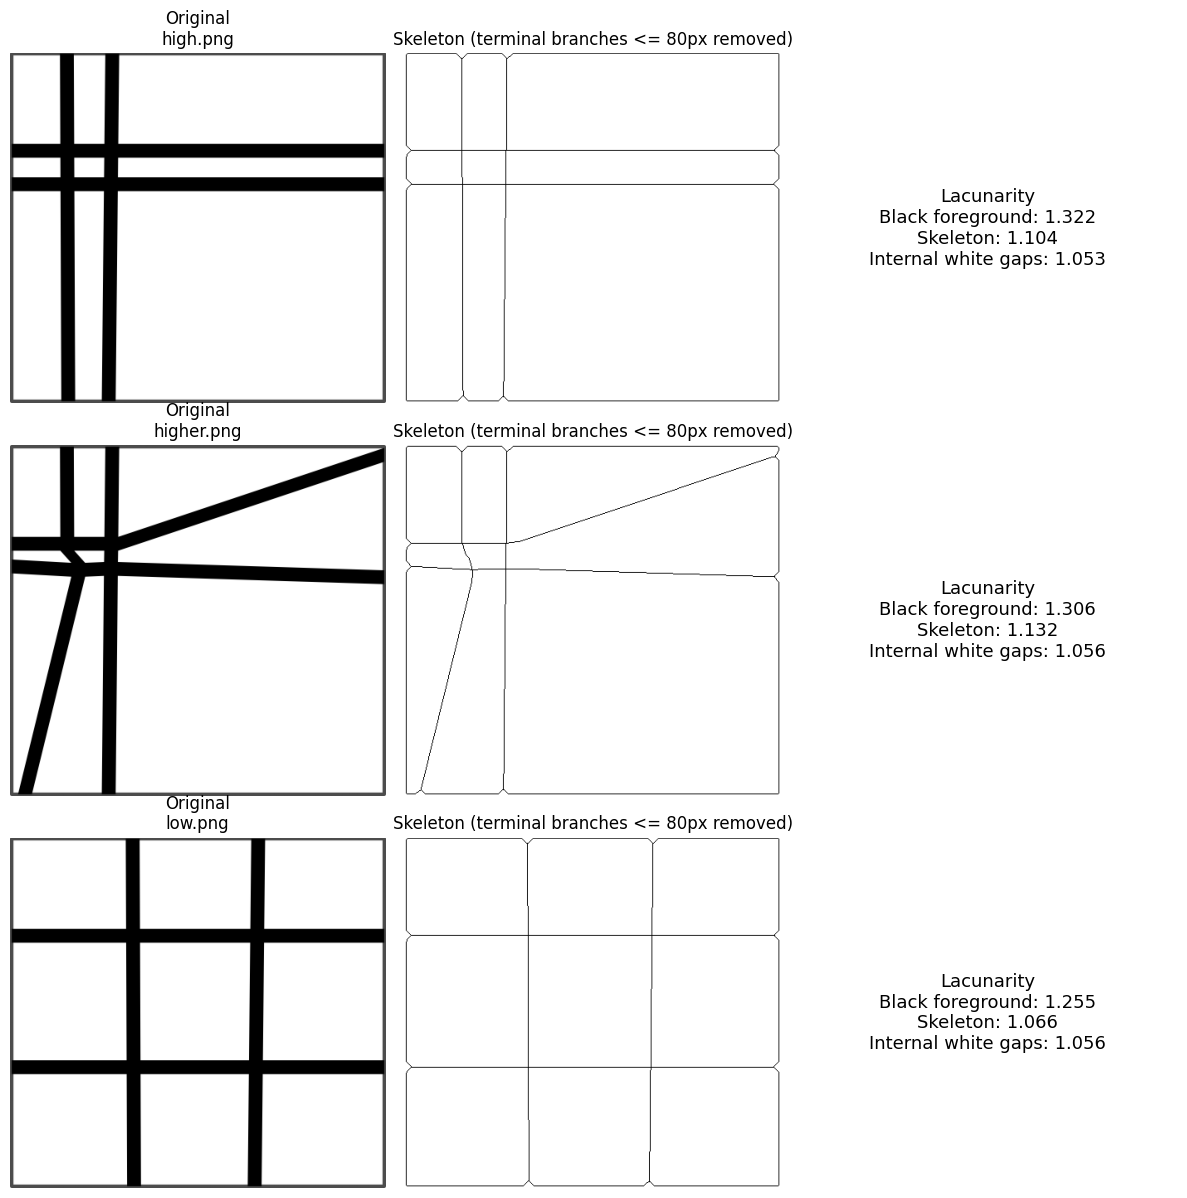

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import util
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize
from scipy.ndimage import label

def load_png_grayscale(path: Path) -> np.ndarray:
    img = Image.open(path)
    # Handle transparency: composite onto white so transparent background is not treated as black.
    if "A" in img.getbands():
        rgba = img.convert("RGBA")
        white_bg = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
        img = Image.alpha_composite(white_bg, rgba).convert("L")
    else:
        img = img.convert("L")
    return np.array(img, dtype=np.float32)

def prune_small_terminal_branches(skeleton: np.ndarray, max_branch_length: int = 12, max_passes: int = 25) -> np.ndarray:
    skel = skeleton.astype(bool).copy()
    h, w = skel.shape

    neighbor_offsets = [
        (dr, dc)
        for dr in (-1, 0, 1)
        for dc in (-1, 0, 1)
        if not (dr == 0 and dc == 0)
    ]

    def neighbors_of(r: int, c: int):
        out = []
        for dr, dc in neighbor_offsets:
            rr, cc = r + dr, c + dc
            if 0 <= rr < h and 0 <= cc < w and skel[rr, cc]:
                out.append((rr, cc))
        return out

    for _ in range(max_passes):
        endpoints = np.argwhere(skel)
        endpoints = [(int(r), int(c)) for r, c in endpoints if len(neighbors_of(int(r), int(c))) == 1]
        if not endpoints:
            break

        to_remove = set()
        for start in endpoints:
            if not skel[start]:
                continue

            path = [start]
            prev = None
            cur = start
            stop_reason = "none"

            while True:
                nbrs = [n for n in neighbors_of(*cur) if n != prev]

                if len(nbrs) == 0:
                    stop_reason = "dead_end"
                    break

                if len(nbrs) > 1:
                    stop_reason = "junction"
                    break

                nxt = nbrs[0]
                path.append(nxt)

                if len(path) > max_branch_length:
                    stop_reason = "too_long"
                    break

                prev, cur = cur, nxt
                degree = len(neighbors_of(*cur))
                if degree == 1:
                    stop_reason = "other_endpoint"
                    break
                if degree >= 3:
                    stop_reason = "junction"
                    break

            if stop_reason in {"dead_end", "other_endpoint", "junction"} and len(path) <= max_branch_length:
                if stop_reason == "junction" and len(path) > 1:
                    to_remove.update(path[:-1])  # keep the junction node itself
                else:
                    to_remove.update(path)

        if not to_remove:
            break

        for r, c in to_remove:
            skel[r, c] = False

    return skel

def internal_gap_mask(binary_foreground: np.ndarray) -> np.ndarray:
    """Return only enclosed white gaps, excluding outer background connected to image border."""
    background = ~binary_foreground.astype(bool)
    labels, _ = label(background)
    if labels.size == 0:
        return np.zeros_like(background, dtype=bool)

    border_labels = set(np.unique(np.concatenate([
        labels[0, :],
        labels[-1, :],
        labels[:, 0],
        labels[:, -1],
    ])))

    enclosed = labels > 0
    for lab in border_labels:
        if lab != 0:
            enclosed[labels == lab] = False
    return enclosed

lacunarity_folder = Path(r"C:\Users\taylorhearn\Dropbox\Diagrams\Affinity_pics\Illustrating_Vascumap_Params\lacunarity\basic")
lacunarity_files = sorted(lacunarity_folder.glob("*.png"))

if not lacunarity_files:
    raise ValueError(f"No PNG files found in {lacunarity_folder}")

max_images = 6
lacunarity_files = lacunarity_files[:max_images]

n = len(lacunarity_files)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

branch_len_px = 80

for row, file_path in enumerate(lacunarity_files):
    gray = load_png_grayscale(file_path)

    try:
        t = threshold_otsu(gray)
    except ValueError:
        t = float(np.mean(gray))

    # Segment dark structures (black) on bright background.
    binary = gray < t

    # Fallback for difficult images where Otsu returns nearly empty/full masks.
    fg_ratio = float(np.mean(binary))
    if fg_ratio < 0.001 or fg_ratio > 0.99:
        binary = gray <= np.percentile(gray, 10)

    skeleton = skeletonize(binary)
    skeleton_pruned = prune_small_terminal_branches(skeleton, max_branch_length=branch_len_px)
    gaps = internal_gap_mask(binary)

    _, lac_full = fractal_dimension_and_lacunarity(binary, remove_branches_first=False)
    _, lac_skel = fractal_dimension_and_lacunarity(skeleton_pruned, remove_branches_first=False)
    _, lac_gaps = fractal_dimension_and_lacunarity(gaps, remove_branches_first=False)

    lac_full_text = f"{lac_full:.3f}" if np.isfinite(lac_full) else "NaN"
    lac_skel_text = f"{lac_skel:.3f}" if np.isfinite(lac_skel) else "NaN"
    lac_gaps_text = f"{lac_gaps:.3f}" if np.isfinite(lac_gaps) else "NaN"
    
    axes[row, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"Original\n{file_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(util.invert(skeleton_pruned), cmap="gray")
    axes[row, 1].set_title(f"Skeleton (terminal branches <= {branch_len_px}px removed)")
    axes[row, 1].axis("off")

    axes[row, 2].text(
        0.5,
        0.5,
        (
        f"Lacunarity\n"
        f"Black foreground: {lac_full_text}\n"
        f"Skeleton: {lac_skel_text}\n"
        f"Internal white gaps: {lac_gaps_text}"
        ),
        ha="center",
        va="center",
        fontsize=13,
    )
    axes[row, 2].set_xlim(0, 1)
    axes[row, 2].set_ylim(0, 1)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("lacunarity.pdf")
plt.show()

In [2]:

import napari
import numpy as np
import pickle
import pandas as pd
import colorsys
import matplotlib.colors as mcolors
from pathlib import Path

d = Path(r"C:\Users\taylorhearn\git_repos\vascumap\working_outputs_double_crop\analysis_outputs_Daisy10")

# --- load arrays ---
clean_segmentation = np.load(d / "clean_segmentation.npy")
binary_edt = np.load(d / "binary_edt.npy")
skeleton = np.load(d / "skeleton.npy")
area_image = np.load(d / "area_image.npy")
skeleton_from_graph = np.load(d / "skeleton_from_graph.npy")
holes = np.load(d / "holes.npy")
hole_labels_per_slice = np.load(d / "hole_labels_per_slice.npy")
hole_distance_per_slice_um = np.load(d / "hole_distance_per_slice_um.npy")
voxel_size_um = np.load(d / "voxel_size_um.npy")

# --- load graphs ---
with open(d / "graph_raw.pkl", "rb") as f:
    graph = pickle.load(f)
with open(d / "graph_pruned.pkl", "rb") as f:
    pruned_graph = pickle.load(f)
with open(d / "graph_clean.pkl", "rb") as f:
    clean_graph = pickle.load(f)

# --- load metrics ---
global_metrics_df = pd.read_csv(d / "global_metrics.csv")


def custom_napari_palette(n_labels, base_colour, hue_span=0.02, sat_span=0.45, light_span=0.45, seed=0, alpha=1.0):
    n_labels = int(n_labels)
    if n_labels < 1:
        return {0: np.array([0.0, 0.0, 0.0, 0.0], dtype=float)}
    rng = np.random.default_rng(seed)
    r, g, b = mcolors.to_rgb(base_colour)
    base_h, base_l, base_s = colorsys.rgb_to_hls(r, g, b)
    hue = (base_h + rng.uniform(-hue_span, hue_span, n_labels)) % 1.0
    sat = np.clip(base_s + rng.uniform(-sat_span, sat_span, n_labels), 0.20, 1.00)
    light = np.clip(base_l + rng.uniform(-light_span, light_span, n_labels), 0.18, 0.88)
    order = rng.permutation(n_labels)
    custom_colormap = {0: np.array([0.0, 0.0, 0.0, 0.0], dtype=float)}
    for idx, j in enumerate(order, start=1):
        pr, pg, pb = colorsys.hls_to_rgb(float(hue[j]), float(light[j]), float(sat[j]))
        custom_colormap[idx] = np.array([pr, pg, pb, float(alpha)], dtype=float)
    return custom_colormap


def graph2image(g, shape):
    out = np.zeros(shape, dtype=np.uint8)
    for u, v in g.edges():
        coords = g.get_edge_data(u, v)['pts']
        clipped = np.zeros_like(coords)
        clipped[:, 0] = np.clip(coords[:, 0], 0, shape[0] - 1)
        clipped[:, 1] = np.clip(coords[:, 1], 0, shape[1] - 1)
        clipped[:, 2] = np.clip(coords[:, 2], 0, shape[2] - 1)
        out[clipped[:, 0], clipped[:, 1], clipped[:, 2]] = 1
    return out


def pad_to_shape(arr, target_shape, constant=0):
    """Pad array with zeros at the end of each axis to reach target_shape."""
    pad_width = [(0, max(0, t - s)) for s, t in zip(arr.shape, target_shape)]
    return np.pad(arr, pad_width, mode='constant', constant_values=constant)


# --- build derived arrays before computing common shape ---
from skimage.measure import label as sk_label
holes_labels = sk_label(holes)
full_graph_skeleton = graph2image(graph, clean_segmentation.shape).astype(np.int32)
clean_graph_skeleton = skeleton_from_graph.astype(np.int32)

# --- find common shape and report any mismatches ---
all_arrays = {
    'clean_segmentation': clean_segmentation,
    'holes_labels': holes_labels,
    'hole_labels_per_slice': hole_labels_per_slice,
    'hole_distance_per_slice_um': hole_distance_per_slice_um,
    'full_graph_skeleton': full_graph_skeleton,
    'clean_graph_skeleton': clean_graph_skeleton,
}
shapes = {k: v.shape for k, v in all_arrays.items()}
print("Shapes before padding:")
for k, s in shapes.items():
    print(f"  {k}: {s}")

target_shape = tuple(max(s[i] for s in shapes.values()) for i in range(3))
print(f"\nTarget shape (max across all): {target_shape}")

clean_segmentation    = pad_to_shape(clean_segmentation.astype(np.int32), target_shape)
holes_labels          = pad_to_shape(holes_labels.astype(np.int32), target_shape)
hole_labels_per_slice = pad_to_shape(hole_labels_per_slice.astype(np.int32), target_shape)
hole_distance_per_slice_um = pad_to_shape(hole_distance_per_slice_um.astype(np.float32), target_shape)
full_graph_skeleton   = pad_to_shape(full_graph_skeleton, target_shape)
clean_graph_skeleton  = pad_to_shape(clean_graph_skeleton, target_shape)

max_label = int(hole_labels_per_slice.max())

# --- napari viewer ---
viewer = napari.Viewer(ndisplay=3)

viewer.add_labels(
    clean_segmentation,
    name='clean_segmentation',
    colormap=custom_napari_palette(1, 'dodgerblue', hue_span=0, sat_span=0, light_span=0),
    opacity=0.35,
)
viewer.add_labels(
    holes_labels,
    name='holes',
    colormap=custom_napari_palette(len(np.unique(holes_labels)), 'red', hue_span=0.1, sat_span=0.1, light_span=0.1),
    opacity=0.6,
)
viewer.add_labels(
    hole_labels_per_slice,
    name='pore_labels',
    colormap=custom_napari_palette(max_label, 'limegreen', hue_span=0.2, sat_span=0.5, light_span=0.5),
    opacity=0.8,
)
viewer.add_image(
    hole_distance_per_slice_um,
    name='hole_distance_per_slice_um',
    colormap='greens',
    opacity=0.45,
)
viewer.add_labels(
    full_graph_skeleton,
    name='full_graph_skeleton',
    colormap=custom_napari_palette(1, 'gold', hue_span=0, sat_span=0, light_span=0),
    opacity=1,
)
viewer.add_labels(
    clean_graph_skeleton,
    name='clean_graph_skeleton',
    colormap=custom_napari_palette(1, 'darkviolet', hue_span=0, sat_span=0, light_span=0),
    opacity=1,
)

# Graph nodes (sprout/junction)
node_ids = list(clean_graph.nodes())
node_pts = np.array([clean_graph.nodes[n]['pts'] for n in node_ids], dtype=float)
if len(node_pts) > 0:
    is_sprout = np.array([bool(clean_graph.nodes[n].get('sprout', False)) for n in node_ids], dtype=bool)
    junction_pts = node_pts[~is_sprout]
    sprout_pts = node_pts[is_sprout]
    if len(junction_pts) > 0:
        viewer.add_points(junction_pts, name='graph_nodes_junction', face_color='limegreen', size=5)
    if len(sprout_pts) > 0:
        viewer.add_points(sprout_pts, name='graph_nodes_sprout', face_color='cyan', size=5)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\taylorhearn\\git_repos\\vascumap\\working_outputs_double_crop\\analysis_outputs_Daisy10\\clean_segmentation.npy'